In [10]:
import sys
import os

src_path = os.path.abspath(os.path.join("..", "..", "src"))
sys.path.append(src_path)

In [11]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
import spikeinterface.extractors as se
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
from plotting import rsp_plot

path = r'C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\TestData\20250414_102411_3_20_sprite_merged.rec'




## Stream ID: Trodes = EKG, ECU = Resp 

In [12]:
rec = se.read_spikegadgets(path, stream_id='trodes')
print(rec)

SpikeGadgetsRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 2,380,676 samples 
                                119.03s (1.98 minutes) - int16 dtype - 145.30 MiB
  file_path: C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\TestData\20250414_102411_3_20_sprite_merged.rec


In [13]:
# Sampling frequency (Hz)
fs = rec.get_sampling_frequency()
print("Sampling frequency:", fs)

# Number of channels
n_channels = rec.get_num_channels()
print("Number of channels:", n_channels)

# Channel IDs (usually integers)
channel_ids = rec.get_channel_ids()
print("Channel IDs:", channel_ids)

# Total number of samples (frames)
n_samples = rec.get_num_frames()
print("Number of samples (frames):", n_samples)

# Duration in seconds
duration_sec = n_samples / fs
print("Duration (seconds):", duration_sec)

Sampling frequency: 20000.0
Number of channels: 32
Channel IDs: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '30' '31']
Number of samples (frames): 2380676
Duration (seconds): 119.0338


In [14]:
# Get the raw data shape (n_channels, n_samples)
rec_shape = rec.get_traces().shape
n_channels = rec.get_num_channels()
n_samples = rec.get_num_frames()
channel_ids = rec.get_channel_ids()

# Sampling frequency
fs = rec.get_sampling_frequency()

# Duration (in seconds)
duration = n_samples / fs

# Optional: start time (SpikeInterface assumes 0 by default)
start_time = 0.0

# Print it all
print("channel IDs:", channel_ids)
print("Shape (samples x channels):", rec_shape)
print("Sampling frequency (Hz):", fs)
print("Number of samples:", n_samples)
print("Number of channels:", n_channels)
print("Duration (s):", duration)
print("Start time (default):", start_time)


channel IDs: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '30' '31']
Shape (samples x channels): (2380676, 32)
Sampling frequency (Hz): 20000.0
Number of samples: 2380676
Number of channels: 32
Duration (s): 119.0338
Start time (default): 0.0


In [15]:
boris_data = r'C:\Users\ADMIN\Desktop\Code\researchProjs\respiratory_pilot\testing_data\22_rehouse_d4_OM.csv'
boris_df = pd.read_csv(boris_data)

boris_df["Start (s)"] = boris_df["Start (s)"] - 600
boris_df["Stop (s)"] = boris_df["Stop (s)"] - 600

boris_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ADMIN\\Desktop\\Code\\researchProjs\\respiratory_pilot\\testing_data\\22_rehouse_d4_OM.csv'

In [24]:
# Get index of channel 21 — channel IDs might be strings, so convert to match
channel_ids = rec.get_channel_ids()

# This will return shape (n_samples,)
channel_21_data = rec.get_traces(channel_ids=['21']).squeeze()

print("Channel 21 data shape:", channel_21_data.shape)
print("First 10 values:", channel_21_data[:10])


Channel 21 data shape: (2380676,)
First 10 values: [ 904  911 1075 1335 1567 1575 1611 1559 1551 1623]


In [25]:
ekg_df = rsp_plot.Rsp_Kit(
    resp_data=channel_21_data,
    fs=fs,
    start_time=start_time,
    size=n_samples,
    end_time=None,
	behavior_data=boris_df,
)

In [31]:
n_samples = int(fs * 2.3)  # Number of samples for 2.2 seconds

# View the first 2.2 seconds of the signal
print(ekg_df.df.head(n_samples).to_string())

       Timestamps  Respiration Value Behavioral Event   Peaks
0         0.00000                904             None   904.0
1         0.00005                911             None     NaN
2         0.00010               1075             None     NaN
3         0.00015               1335             None     NaN
4         0.00020               1567             None     NaN
5         0.00025               1575             None     NaN
6         0.00030               1611             None  1611.0
7         0.00035               1559             None     NaN
8         0.00040               1551             None  1551.0
9         0.00045               1623             None  1623.0
10        0.00050               1571             None  1571.0
11        0.00055               1631             None  1631.0
12        0.00060               1554             None  1554.0
13        0.00065               1578             None     NaN
14        0.00070               1602             None  1602.0
15      

C:\Users\ADMIN\Desktop\Code\researchProjs\respiratory_pilot\src\plotting\rsp_plot.py:336: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


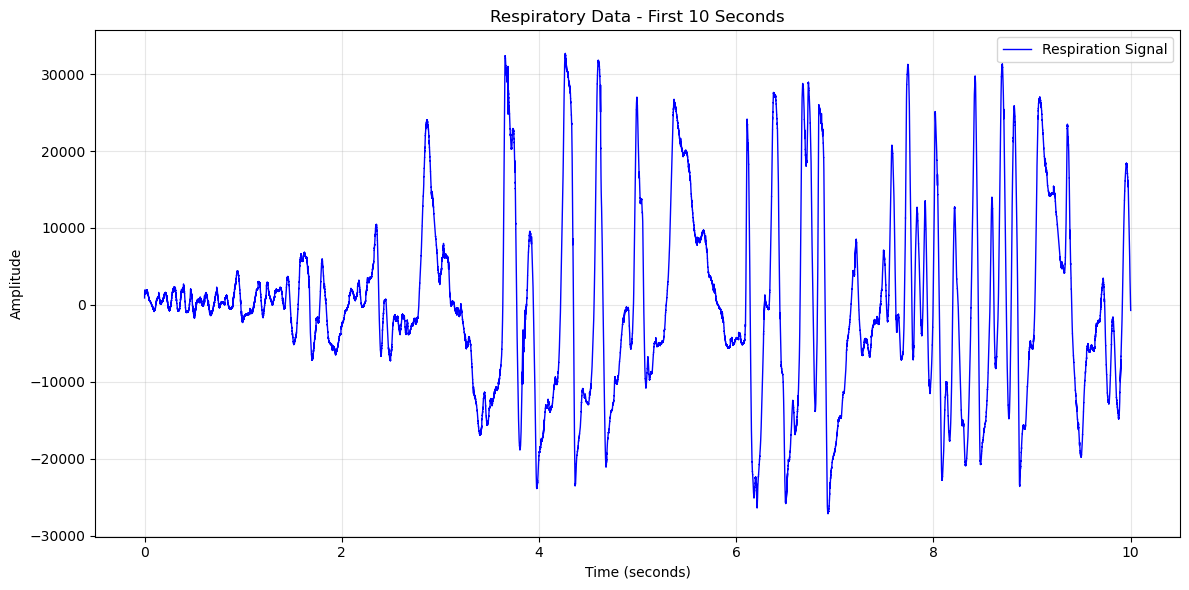

In [32]:
ekg_df.plot()